In [160]:
from spidercat.generate import minimum_E_and_V

n, T = 22, 5

num_edges, num_vertices = minimum_E_and_V(n, T)
print(num_edges, num_vertices)

33 22


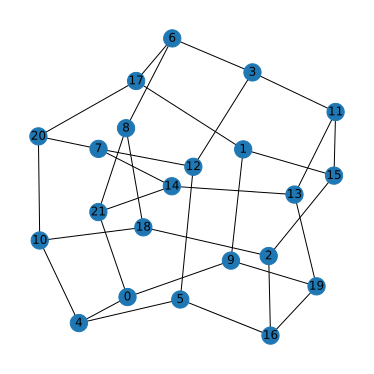

In [161]:
from spidercat.graphs_random import generate_3regular_graph_with_no_nonlocal_t_cut
from spidercat.draw import visualize_cat_state_base, draw_spanning_forest_solution

G = generate_3regular_graph_with_no_nonlocal_t_cut(num_vertices, T)
visualize_cat_state_base(G, [], {})

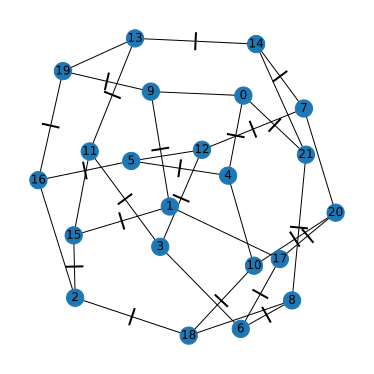

In [162]:
from spidercat.markings import GraphMarker

marker = GraphMarker(G, max_marks=n)
marks = marker.find_solution(T)

visualize_cat_state_base(G, [], marks)

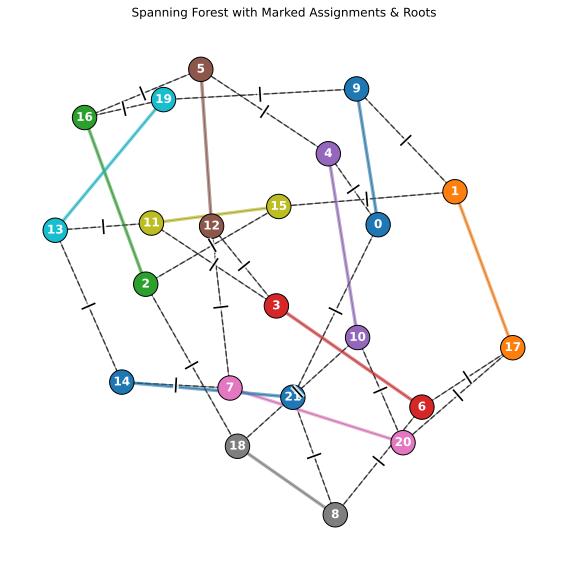

In [163]:
from spidercat.spanning_tree import build_trivial_spanning_forest, build_min_diameter_spanning_tree

forest = build_trivial_spanning_forest(G, marks)
draw_spanning_forest_solution(G, forest, marks, figsize=(8,8))

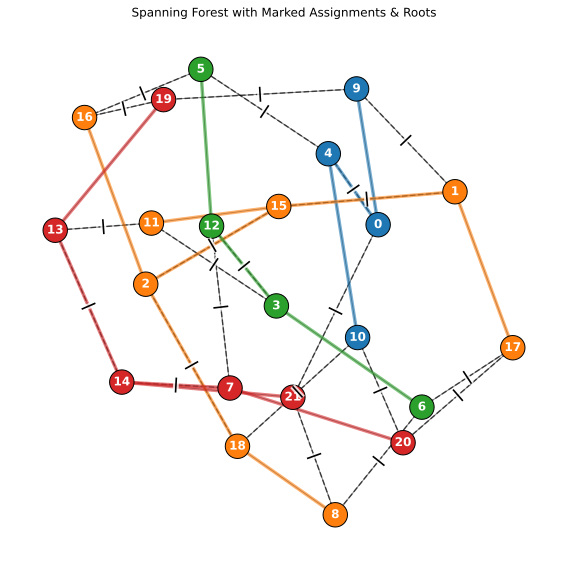

In [166]:
tree = build_min_diameter_spanning_tree(G, forest, marks, 4)
draw_spanning_forest_solution(G, tree, marks, figsize=(8,8))

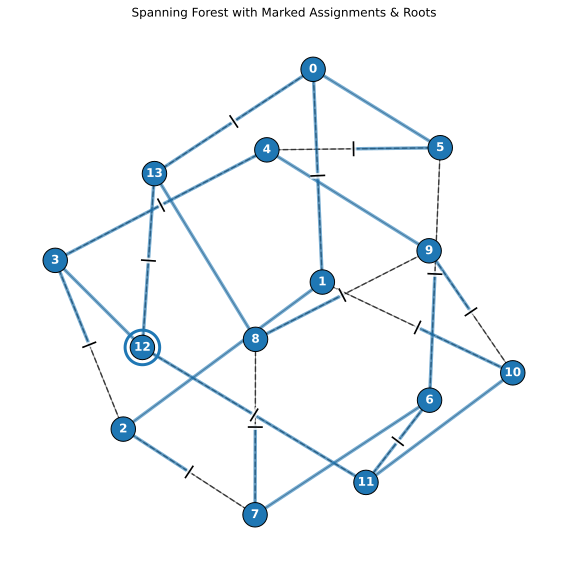

In [142]:
from spidercat.spanning_tree import match_forest_leaves_to_marked_edges, find_min_height_roots

matchings = match_forest_leaves_to_marked_edges(G, tree, marks)
roots = find_min_height_roots(tree)
draw_spanning_forest_solution(G, tree, marks, matchings, roots, figsize=(8,8))

=== Starting Elegant Extraction (BFS) ===
Init Root 12 (Tree 0) -> Q0
  Node 12 -> Branch 26: Spawned CNOT Q0 -> Q1
  Node 12 -> Branch 27: Spawned CNOT Q0 -> Q2
  Node 12 -> Primary 3 (Inherits Q0)
  Mark on 26: Spawned CNOT Q1 -> Q3
  Node 26 -> Primary 11 (Inherits Q1)
  Mark on 27: Spawned CNOT Q2 -> Q4
  Node 27 -> Primary 13 (Inherits Q2)
  Node 3 -> Branch 19: Spawned CNOT Q0 -> Q5
  Node 3 -> Primary 17 (Inherits Q0)
  Node 11 -> Branch 22: Spawned CNOT Q1 -> Q6
  Node 11 -> Primary 10 (Inherits Q1)
  Node 13 -> Branch 15: Spawned CNOT Q2 -> Q7
  Node 13 -> Primary 8 (Inherits Q2)
  Mark on 19: Spawned CNOT Q5 -> Q8
  Node 19 -> Primary 4 (Inherits Q5)
  New flag initialised (17, 2): CNOT Q0 -> Q14
  Node 17 serves as a sink point for Q0
  Mark on 22: Spawned CNOT Q6 -> Q9
  Node 22 -> Primary 6 (Inherits Q6)
  New flag initialised (10, 25): CNOT Q1 -> Q15
  Node 10 -> Primary 16 (Inherits Q1)
  Mark on 15: Spawned CNOT Q7 -> Q10
  Node 15 -> Primary 0 (Inherits Q7)
  New flag 

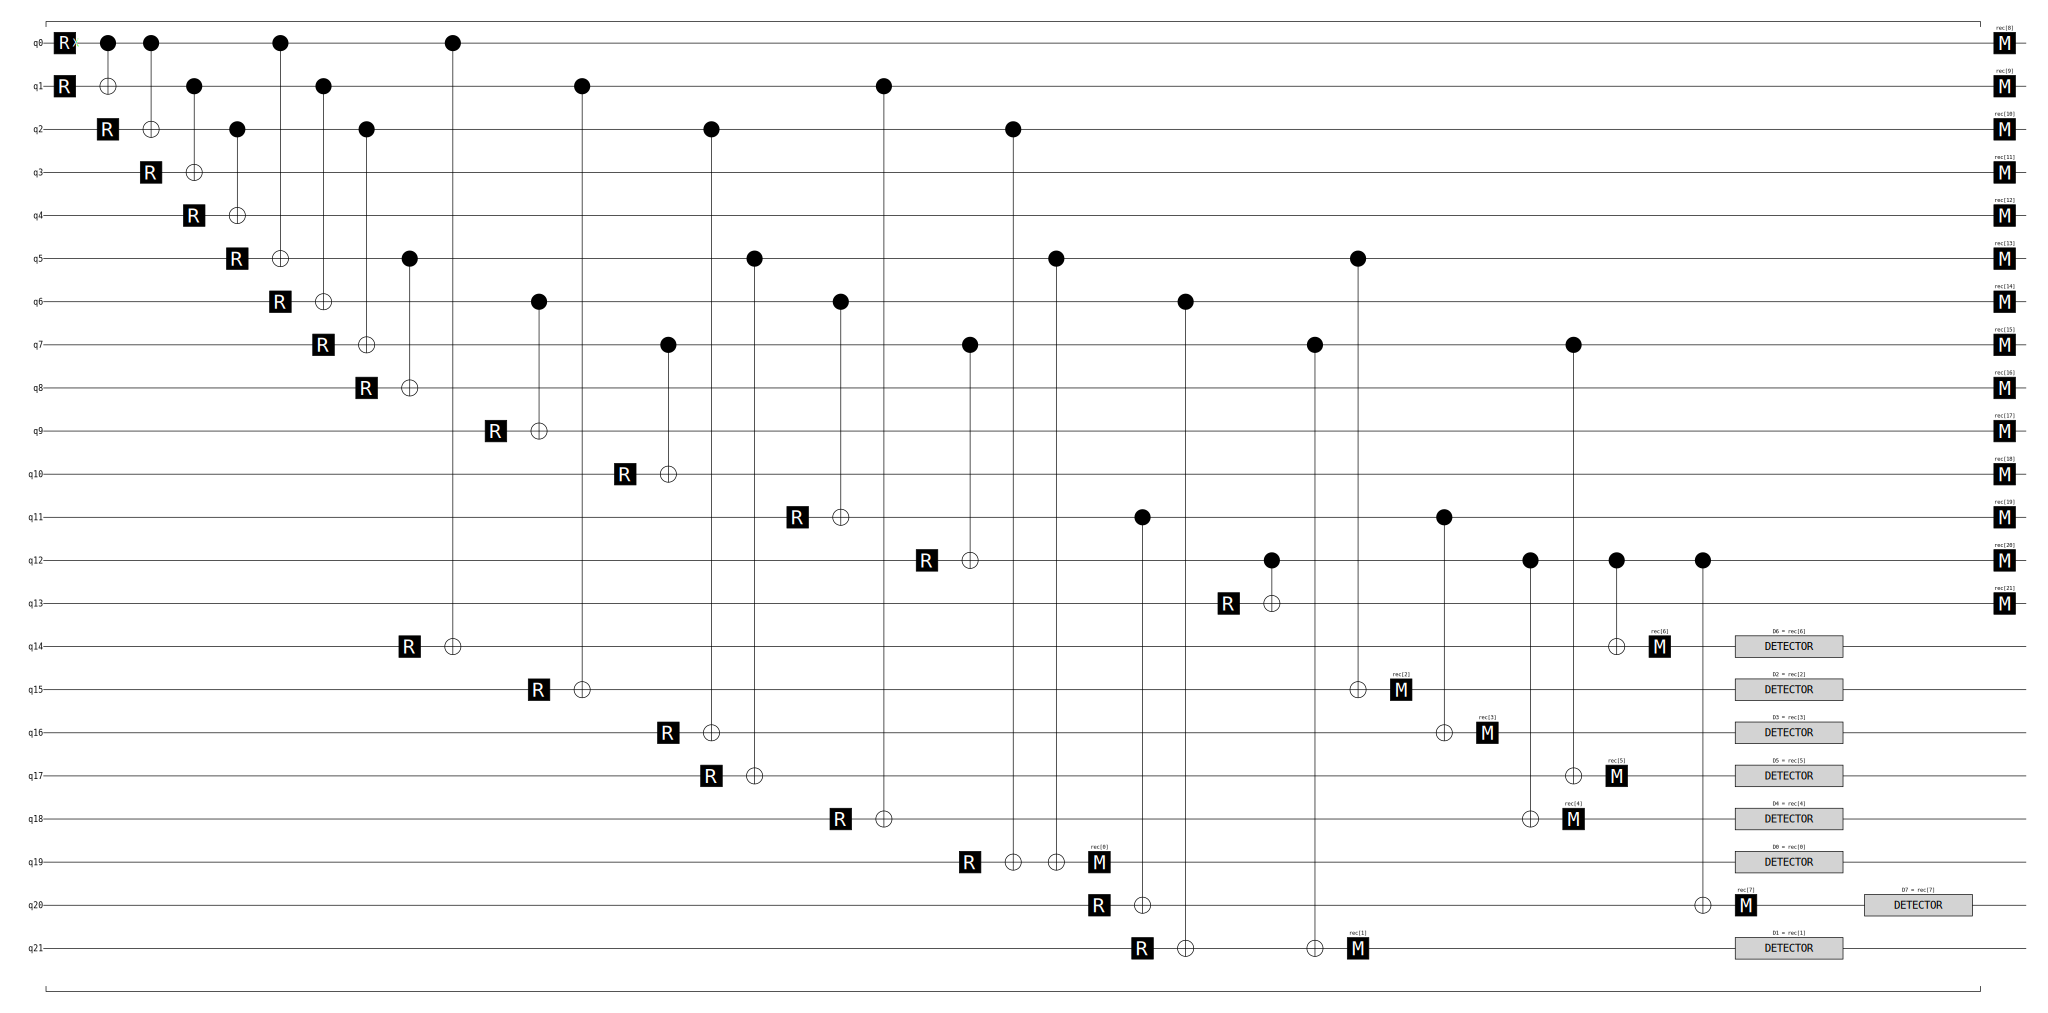

In [143]:
from spidercat.circuit_extraction import extract_circuit_rooted

circ = extract_circuit_rooted(G, tree, roots, marks, matchings, verbose=True)
circ.append("TICK", [])
circ.append("M", range(n))
circ.diagram('timeline-svg')

In [145]:
samples = circ.compile_sampler().sample(10)
converter = circ.compile_m2d_converter()

print(samples[:,-n:].astype(int))
l, d = converter.convert(measurements=samples, separate_observables=True)
print()
print(samples[:,:-n].astype(int))

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
